# Parameter Inference
The availability of exact moments lends itself to gradient-based parameter estimation. This is commonly done based on the SFS, but higher-order moments are also thinkable, provided they can be computed from the data at hand. ``phasegen`` provides a lightweight framework for performing parameter inference which is done by defining an {class}`~phasegen.inference.Inference` object.

In [1]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [4.4, 3.3]

## Running an inference
{class}`~phasegen.inference.Inference` requires a parametrized coalescent distribution, a loss function, and parameter bounds to be specified. More specifically, the `coal` argument is a callable that returns a {class}`~phasegen.distributions.Coalescent` object, based on the parameter values of the current optimization step, and `loss` is a callable specifying the current loss. By default, 10 independent optimization runs are performed using the L-BFGS-B algorithm, and the best result is returned. 

Below we optimize a two-epoch demography where the time of the size change (``t``) and the resulting population size (``Ne``) are variable. The observed summary statistic is an SFS with a sample size of 10, and the loss function is the Poisson likelihood.

In [14]:
import phasegen as pg

observation = pg.SFS(
    [177130, 997, 441, 228, 156, 117, 114, 83, 105, 109, 652]
)

inf = pg.Inference(
    bounds=dict(t=(0, 4), Ne=(0.1, 1)),
    coal=lambda t, Ne: pg.Coalescent(
        n=10,
        demography=pg.Demography(
            pop_sizes={'pop_0': {0: 1, t: Ne}}
        )
    ),
    loss=lambda coal, _: pg.PoissonLikelihood().compute(
        observed=observation.normalize().polymorphic,
        modelled=coal.sfs.mean.normalize().polymorphic
    )
)

Upon construction, the inference object is ready to be optimized and the result can be visualized.

In [15]:
inf.run()

Optimizing: 100%|██████████| 10/10 [00:42<00:00,  4.22s/it]
INFO:Inference: Inferred parameters: (t=0.1455, Ne=0.4813)


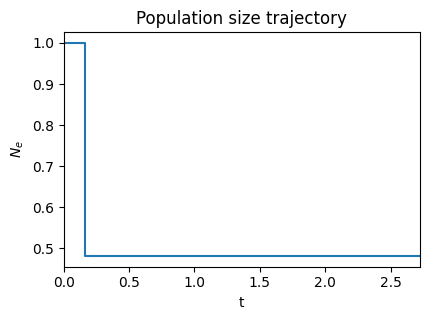

In [16]:
inf.plot_pop_sizes();

## Parametric bootstrapping
We may also wish to perform parametric bootstrapping. In order to do this, we provide a callback function to resample the data, and set `do_bootstrap=True`. Note that we specify {attr}`~phasegen.inference.Inference.observation` to {class}`~phasegen.inference.Inference`, which is necessary for the resampling to work.

In [17]:
inf = pg.Inference(
    bounds=dict(t=(0, 4), Ne=(0.1, 1)),
    observation=pg.SFS(
        [177130, 997, 441, 228, 156, 117, 114, 83, 105, 109, 652]
    ),
    coal=lambda t, Ne: pg.Coalescent(
        n=10,
        demography=pg.Demography(
            pop_sizes={'pop_0': {0: 1, t: Ne}}
        )
    ),
    loss=lambda coal, obs: pg.PoissonLikelihood().compute(
        observed=obs.normalize().polymorphic,
        modelled=coal.sfs.mean.normalize().polymorphic
    ),
    resample=lambda sfs, _: sfs.resample(),
    do_bootstrap=True
)

Let's run the inference again and visualize the results.

In [18]:
inf.run()

Optimizing: 100%|██████████| 10/10 [01:04<00:00,  6.46s/it]
INFO:Inference: Inferred parameters: (t=0.1455, Ne=0.4814)
Bootstrapping: 100%|██████████| 100/100 [02:47<00:00,  1.67s/it]


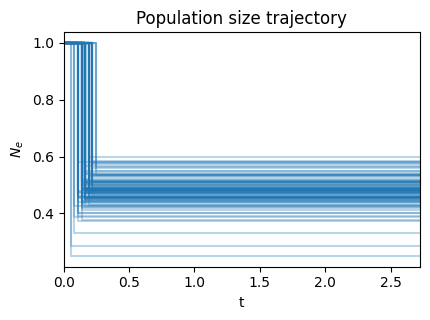

In [19]:
inf.plot_pop_sizes();

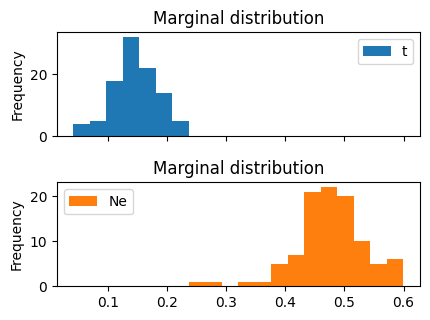

In [20]:
inf.plot_bootstraps();

## Distributed bootstrapping
Whenever running inference with long runtimes, you might want to distribute the bootstrapping process. This can be done by creating bootstrap samples which are {class}`~phasegen.inference.Inference` objects themselves ({meth}`~phasegen.inference.Inference.create_bootstrap`). These bootstraps can be run in parallel and the results combined afterwards ({meth}`~phasegen.inference.Inference.add_bootstrap`). Below is an example [Snakemake](https://snakemake.readthedocs.io/en/stable/) workflow for distributed bootstrapping: 

``Snakefile``:

In [ ]:
rule all:
    input:
        "results/graphs/inference/demography.png",

# setup inference and perform initial run
rule setup_inference:
    output:
        "results/inference/inference.json"
    conda:
        "phasegen.yaml"
    script:
        "setup_inference.py"

# create and run bootstrap
rule run_bootstrap:
    input:
        "results/inference/inference.json"
    output:
        "results/inference/bootstraps/{i}/inference.json"
    conda:
        "phasegen.yaml"
    script:
        "run_bootstrap.py"

# merge bootstraps and visualize
rule merge_bootstraps:
    input:
        inference="results/inference/inference.json",
        bootstraps=expand("results/inference/bootstraps/{i}/inference.json",i=range(100))
    output:
        inference="results/inference/inference.bootstrapped.json",
        demography="results/graphs/inference/demography.png",
        bootstraps="results/graphs/inference/bootstraps.png",
    conda:
        "phasegen.yaml"
    script:
        "merge_bootstraps.py"

where ``phasegen.yaml`` is a conda environment file with the following content:
```yaml
name: phasegen
channels:
  - defaults
dependencies:
  - python>=3.10,<3.14
  - pip
  - pip:
      - phasegen
```

In ``setup_inference.py``, we set up the inference object, perform the initial run and save the results to a file. Note that bootstrapping is disabled here as we are doing it manually.

In [ ]:
import phasegen as pg
out = snakemake.output[0]

inf = pg.Inference(
    bounds=dict(t=(0, 4), Ne=(0.1, 1)),
    observation=pg.SFS(
        [177130, 997, 441, 228, 156, 117, 114, 83, 105, 109, 652]
    ),
    coal=lambda t, Ne: pg.Coalescent(
        n=10,
        demography=pg.Demography(
            pop_sizes={'pop_0': {0: 1, t: Ne}}
        )
    ),
    loss=lambda coal, obs: pg.PoissonLikelihood().compute(
        observed=obs.normalize().polymorphic,
        modelled=coal.sfs.mean.normalize().polymorphic
    ),
    resample=lambda sfs, _: sfs.resample(),
    do_bootstrap=False
)

inf.run()

inf.to_file(out)

In ``run_bootstrap.py``, we load the inference object from the file, create a bootstrap sample and run the inference for it. This will use the specified resampling function to resample the SFS.

In [ ]:
import phasegen as pg

file = snakemake.input[0]
out = snakemake.output[0]

inf = pg.Inference.from_file(file)

bootstrap = inf.create_bootstrap()

bootstrap.run()

bootstrap.to_file(out)

In ``merge_bootstraps.py``, we load the inference object and all bootstraps, merge the bootstraps with the main inference object and visualize the results.

In [ ]:
import phasegen as pg

inf_file = snakemake.input.inference
bootstraps_file = snakemake.input.bootstraps
out = snakemake.output.inference
out_demography = snakemake.output.demography
out_bootstraps = snakemake.output.bootstraps

inf = pg.Inference.from_file(inf_file)

inf.add_bootstraps([pg.Inference.from_file(f) for f in bootstraps_file])

inf.plot_demography(file=out_demography)
inf.plot_bootstraps(file=out_bootstraps)

inf.to_file(out)